# System 2107: Environment Audit and Cleaning
- Inputs: environment CSV and supporting metadata only. The audit preserves raw values; approved unit-only processing follows below. No resampling, filling, or timezone localization.
- Full-file statistics; selected neighborhoods/windows are labeled examples. The narrow 7.7 MB file fits in memory.
- Run from the repository root or `notebooks/` with pandas and NumPy. SVG plots need no plotting package.
- Retain raw timestamp strings. Numeric/time parsing creates diagnostic series; missing tokens follow pandas' default CSV NA vocabulary.

In [1]:
from pathlib import Path
from datetime import datetime,timedelta
from collections import Counter
import csv,json,hashlib,html,platform
import numpy as np
import pandas as pd
try:
    from IPython.display import display,SVG
except ImportError:
    def display(obj):
        print(obj.to_string() if isinstance(obj,(pd.Series,pd.DataFrame)) else obj)
    def SVG(data): return data
ROOT=Path.cwd()
if not (ROOT/'data/2107/raw/2107_environment_data.csv').is_file(): ROOT=ROOT.parent
CSV=ROOT/'data/2107/raw/2107_environment_data.csv'
META=ROOT/'data/2107/raw/2107_system_metadata.json'
assert CSV.is_file() and META.is_file(), 'Run from repository root or notebooks/'
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
input_hashes={str(p.relative_to(ROOT)):sha256(p) for p in (CSV,META)}
metadata=json.loads(META.read_text(encoding='utf-8'))
print('File:',CSV.relative_to(ROOT),'bytes:',CSV.stat().st_size)
print('Python:',platform.python_version(),'pandas:',pd.__version__,'NumPy:',np.__version__)

File: data\2107\raw\2107_environment_data.csv bytes: 7700486
Python: 3.11.9 pandas: 3.0.6 NumPy: 2.4.6


## 1. Schema and metadata
Check record widths/header duplicates before pandas inference. Report every column and supporting sensor/metric/unit information; no scales or offsets are applied.

In [2]:
with CSV.open(newline='',encoding='utf-8-sig') as f:
    reader=csv.reader(f); header=next(reader); record_count=0; bad_widths=[]
    for row in reader:
        record_count+=1
        if len(row)!=len(header): bad_widths.append((record_count,len(row)))
print('Rows:',record_count,'columns:',len(header),'names:',header)
print('Header duplicates:',{k:v for k,v in Counter(header).items() if v>1},'wrong-width rows:',bad_widths[:10])
assert not bad_widths and len(set(header))==len(header), 'Review structural anomalies before continuing'
TIMESTAMP='measured_on'
assert TIMESTAMP in header
CHANNELS=[c for c in header if c!=TIMESTAMP]
frame=pd.read_csv(CSV,dtype={c:'str' for c in CHANNELS},converters={TIMESTAMP:str})
assert len(frame)==record_count
inferred={c:set() for c in header}
for chunk in pd.read_csv(CSV,chunksize=50000):
    for c in header: inferred[c].add(str(chunk[c].dtype))
del chunk
display(pd.DataFrame({'column':header,'inferred_dtypes':[', '.join(sorted(inferred[c])) for c in header]}))
print('Timestamp:',TIMESTAMP,'environment channels:',len(CHANNELS),'duplicate parsed-field rows:',int(frame.duplicated().sum()))
print('First records (example only):'); display(frame.head())
expected_units={'ambient_temperature_o_149575':'F','wind_speed_o_149576':'mph','wind_direction_o_149577':'degree'}
checks=[]
for c in CHANNELS:
    m=metadata['Metrics'].get(c,{})
    checks.append(dict(column=c,metadata_present=bool(m),metric_id=m.get('metric_id'),
        metric_id_matches=str(m.get('metric_id'))==c.rsplit('_',1)[-1],sensor_name=m.get('sensor_name'),
        sensor_name_matches=m.get('sensor_name','').split(' (')[0]==c.rsplit('_o_',1)[0],
        raw_units=m.get('raw_units'),units=m.get('units'),units_match=m.get('units')==expected_units.get(c),
        raw_units_match=m.get('raw_units')==expected_units.get(c),aggregation=m.get('aggregation_type'),
        source_id=m.get('source_id'),scale=m.get('calc_scale'),offset=m.get('calc_offset')))
metadata_check=pd.DataFrame(checks); display(metadata_check)
print('Metadata mismatches:')
display(metadata_check.loc[~metadata_check[['metadata_present','metric_id_matches','sensor_name_matches','units_match','raw_units_match']].all(axis=1)])
print('Expected channels absent:',sorted(set(expected_units)-set(CHANNELS)))
print('Timezone:',metadata['System'].get('timezone_code'),metadata['System'].get('comments'))
print('System-level bounds:',metadata['System'].get('first_timestamp'),metadata['System'].get('last_timestamp'))

Rows: 206008 columns: 4 names: ['measured_on', 'ambient_temperature_o_149575', 'wind_speed_o_149576', 'wind_direction_o_149577']
Header duplicates: {} wrong-width rows: []
Timestamp: measured_on environment channels: 3 duplicate parsed-field rows: 0
First records (example only):
Metadata mismatches:
Expected channels absent: []
Timezone: PST8PDT Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023
System-level bounds: 2018-12-15 00:15:00 2023-11-15 12:21:50


,column,inferred_dtypes
0,measured_on,str
1,ambient_temperature_o_149575,float64
2,wind_speed_o_149576,float64
3,wind_direction_o_149577,float64


,measured_on,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
0,2017-12-01 00:00:00,38.8,1.2,156.0
1,2017-12-01 00:15:00,38.8,1.2,156.0
2,2017-12-01 00:30:00,38.8,1.2,156.0
3,2017-12-01 00:45:00,38.8,1.2,156.0
4,2017-12-01 01:00:00,37.0,2.6,247.0


,column,metadata_present,metric_id,metric_id_matches,sensor_name,sensor_name_matches,raw_units,units,units_match,raw_units_match,aggregation,source_id,scale,offset
0,ambient_temperature_o_149575,True,149575,True,ambient_temperature (F),True,F,F,True,True,sample,None,1.0,0.0
1,wind_speed_o_149576,True,149576,True,wind_speed (mph),True,mph,mph,True,True,sample,None,1.0,0.0
2,wind_direction_o_149577,True,149577,True,wind_direction (degree),True,degree,degree,True,True,sample,None,1.0,0.0


,column,metadata_present,metric_id,metric_id_matches,sensor_name,sensor_name_matches,raw_units,units,units_match,raw_units_match,aggregation,source_id,scale,offset


## 2. Timestamps and DST
Intervals follow file order; raw strings remain unchanged. Comparison uses reviewed electrical/irradiance findings, without opening those CSVs: Pacific spring skips, no repeated fall hour, unresolved fall export behavior.

In [3]:
raw_time=frame[TIMESTAMP]
parsed=pd.to_datetime(raw_time,format='%Y-%m-%d %H:%M:%S',errors='coerce')
seconds=parsed.diff().dt.total_seconds()
print('First/last raw:',raw_time.iloc[0],raw_time.iloc[-1])
print('Parsed bounds:',parsed.min(),parsed.max(),'parse failures:',int(parsed.isna().sum()))
display(frame.loc[parsed.isna(),[TIMESTAMP]])
print('Nondecreasing:',parsed.is_monotonic_increasing,'strictly increasing:',bool(seconds.iloc[1:].gt(0).all()))
print('Raw duplicate timestamps:',int(raw_time.duplicated().sum()),'parsed duplicates:',int(parsed.dropna().duplicated().sum()))
display(frame.loc[raw_time.duplicated(keep=False)].head(20))
interval_counts=seconds.value_counts().sort_index().rename('count').to_frame()
interval_counts['pct_intervals']=100*interval_counts['count']/seconds.notna().sum()
display(interval_counts)
print('Modal cadence (seconds):',float(seconds[seconds>0].mode().iloc[0]))
print('Zero/negative/off-15-minute-grid intervals:',int(seconds.eq(0).sum()),int(seconds.lt(0).sum()),int((seconds.dropna()%900!=0).sum()))
print('Metadata bounds match:',metadata['System'].get('first_timestamp')==raw_time.iloc[0],metadata['System'].get('last_timestamp')==raw_time.iloc[-1])
def sunday(year,month,ordinal):
    d=datetime(year,month,1)
    return d+timedelta(days=(6-d.weekday())%7+7*(ordinal-1))
assert parsed.min().year>=2007
spring_slots=[]; dst_records=[]
for year in range(parsed.min().year,parsed.max().year+1):
    for season,date in [('spring',sunday(year,3,2)),('fall',sunday(year,11,1))]:
        if not parsed.min().normalize()<=date<=parsed.max().normalize(): continue
        day=(parsed>=date)&(parsed<date+timedelta(days=1))
        critical=day & parsed.dt.hour.eq(2 if season=='spring' else 1)
        # Include intervals leaving the transition day, not just those ending on it.
        irregular=(day | day.shift(1,fill_value=False)) & seconds.ne(900) & seconds.notna()
        dst_records.append(dict(year=year,season=season,date=str(date.date()),day_rows=int(day.sum()),
            critical_hour_rows=int(critical.sum()),critical_hour_duplicates=int(raw_time[critical].duplicated().sum()),
            irregular_intervals=[dict(previous=raw_time.iloc[i-1],current=raw_time.iloc[i],seconds=float(seconds.iloc[i])) for i in np.flatnonzero(irregular)]))
        if season=='spring': spring_slots.extend(pd.date_range(date+timedelta(hours=2),periods=4,freq='15min'))
dst_audit=pd.DataFrame(dst_records); display(dst_audit)

First/last raw: 2017-12-01 00:00:00 2023-10-31 23:45:00
Parsed bounds: 2017-12-01 00:00:00 2023-10-31 23:45:00 parse failures: 0
Nondecreasing: True strictly increasing: True
Raw duplicate timestamps: 0 parsed duplicates: 0
Modal cadence (seconds): 900.0
Zero/negative/off-15-minute-grid intervals: 0 0 0
Metadata bounds match: False False


,measured_on


,measured_on,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577


,count,pct_intervals
measured_on,,
900.0,205991,99.992233
4500.0,14,0.006796
123300.0,1,0.000485
1131300.0,1,0.000485


,year,season,date,day_rows,critical_hour_rows,critical_hour_duplicates,irregular_intervals
0,2018,spring,2018-03-11,92,0,0,"[{'previous': '2018-03-11 01:45:00', 'current': '2018-03-11 03:00:00', 'seconds': 4500.0}]"
1,2018,fall,2018-11-04,92,4,0,"[{'previous': '2018-11-04 22:45:00', 'current': '2018-11-05 00:00:00', 'seconds': 4500.0}]"
2,2019,spring,2019-03-10,92,0,0,"[{'previous': '2019-03-10 01:45:00', 'current': '2019-03-10 03:00:00', 'seconds': 4500.0}]"
3,2019,fall,2019-11-03,92,4,0,"[{'previous': '2019-11-03 22:45:00', 'current': '2019-11-04 00:00:00', 'seconds': 4500.0}]"
4,2020,spring,2020-03-08,92,0,0,"[{'previous': '2020-03-08 01:45:00', 'current': '2020-03-08 03:00:00', 'seconds': 4500.0}]"
5,2020,fall,2020-11-01,92,4,0,"[{'previous': '2020-11-01 22:45:00', 'current': '2020-11-02 00:00:00', 'seconds': 4500.0}]"
6,2021,spring,2021-03-14,92,0,0,"[{'previous': '2021-03-14 01:45:00', 'current': '2021-03-14 03:00:00', 'seconds': 4500.0}]"
7,2021,fall,2021-11-07,92,4,0,"[{'previous': '2021-11-07 22:45:00', 'current': '2021-11-08 00:00:00', 'seconds': 4500.0}]"
8,2022,spring,2022-03-13,92,0,0,"[{'previous': '2022-03-13 01:45:00', 'current': '2022-03-13 03:00:00', 'seconds': 4500.0}]"
9,2022,fall,2022-11-06,92,4,0,"[{'previous': '2022-11-06 22:45:00', 'current': '2022-11-07 00:00:00', 'seconds': 4500.0}]"


## 3. Coverage and absent timestamps
- Benchmark: first-to-last 15-minute naive wall-clock slots, inclusive. Diagnostic slots are counted; no data rows are inserted.
- Exclude Pacific spring 02:00-02:45 slots conditionally. Fall ambiguity is unresolved; this is not UTC/elapsed-time coverage.
- Gap endpoints bound observed records. Duration is their separation; candidate absent slots = seconds/900 - 1.
- Short = at most four non-DST absent slots (<=1 hour of benchmark coverage); long = more than four. These are descriptive categories, not filling rules.

In [4]:
assert parsed.notna().all() and parsed.is_monotonic_increasing and not parsed.duplicated().any()
assert (seconds.dropna()%900==0).all(), 'Review off-grid intervals before coverage calculation'
gaps=pd.DataFrame({'gap_start':raw_time.shift(),'gap_end':raw_time,'seconds':seconds}).loc[seconds>900].copy()
gaps['duration']=pd.to_timedelta(gaps.seconds,unit='s')
gaps['expected_15min_missing']=(gaps.seconds/900-1).astype(int)
gaps['dst_spring_slots']=0
observed_index=pd.DatetimeIndex(parsed)
missing_spring=pd.DatetimeIndex(spring_slots).difference(observed_index)
for position,count in Counter(np.searchsorted(parsed.to_numpy(),missing_spring.to_numpy())).items():
    gaps.loc[position,'dst_spring_slots']=count
gaps['non_dst_missing']=gaps.expected_15min_missing-gaps.dst_spring_slots
gaps['category']=np.where(gaps.dst_spring_slots>0,
    np.where(gaps.non_dst_missing==0,'DST spring only','DST plus other missing'),
    np.where(gaps.non_dst_missing<=4,'short non-DST','long non-DST'))
display(gaps)
gap_summary=gaps.groupby('category').agg(periods=('seconds','size'),candidate_slots=('expected_15min_missing','sum'),
    spring_slots=('dst_spring_slots','sum'),non_dst_slots=('non_dst_missing','sum'))
display(gap_summary)
reference=pd.date_range(parsed.iloc[0],parsed.iloc[-1],freq='15min')
assert observed_index.isin(reference).all()
conditional_reference=reference[~reference.isin(pd.DatetimeIndex(spring_slots))]
coverage=dict(wall_clock_duration=str(parsed.iloc[-1]-parsed.iloc[0]),rows=len(frame),naive_expected_slots=len(reference),
    spring_slots_excluded=len(reference)-len(conditional_reference),conditional_expected_slots=len(conditional_reference),
    naive_absent_slots=len(reference)-len(frame),non_dst_absent_slots=len(conditional_reference)-len(frame),
    naive_present_pct=100*len(frame)/len(reference),conditional_present_pct=100*len(frame)/len(conditional_reference))
assert gaps.expected_15min_missing.sum()==coverage['naive_absent_slots']
assert gaps.non_dst_missing.sum()==coverage['non_dst_absent_slots']
display(pd.Series(coverage,name='coverage'))
longest_gap=gaps.loc[gaps.seconds.idxmax()]
expected_year=pd.Series(conditional_reference.year).value_counts().sort_index()
actual_year=parsed.dt.year.value_counts().sort_index()
yearly=pd.DataFrame({'conditional_expected_slots':expected_year,'rows':actual_year})
yearly['present_pct']=100*yearly.rows/yearly.conditional_expected_slots
display(yearly)

,gap_start,gap_end,seconds,duration,expected_15min_missing,dst_spring_slots,non_dst_missing,category
9608,2018-03-11 01:45:00,2018-03-11 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
32536,2018-11-04 22:45:00,2018-11-05 00:00:00,4500.0,0 days 01:15:00,4,0,4,short non-DST
44544,2019-03-10 01:45:00,2019-03-10 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
67472,2019-11-03 22:45:00,2019-11-04 00:00:00,4500.0,0 days 01:15:00,4,0,4,short non-DST
79480,2020-03-08 01:45:00,2020-03-08 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only
94436,2020-08-10 21:45:00,2020-08-12 08:00:00,123300.0,1 days 10:15:00,136,0,136,long non-DST
99240,2020-10-01 08:45:00,2020-10-14 11:00:00,1131300.0,13 days 02:15:00,1256,0,1256,long non-DST
101016,2020-11-01 22:45:00,2020-11-02 00:00:00,4500.0,0 days 01:15:00,4,0,4,short non-DST
106772,2020-12-31 22:45:00,2021-01-01 00:00:00,4500.0,0 days 01:15:00,4,0,4,short non-DST
113692,2021-03-14 01:45:00,2021-03-14 03:00:00,4500.0,0 days 01:15:00,4,4,0,DST spring only


,periods,candidate_slots,spring_slots,non_dst_slots
category,,,,
DST spring only,6,24,24,0
long non-DST,2,1392,0,1392
short non-DST,8,32,0,32


wall_clock_duration           2160 days 23:45:00
rows                                      206008
naive_expected_slots                      207456
spring_slots_excluded                         24
conditional_expected_slots                207432
naive_absent_slots                          1448
non_dst_absent_slots                        1424
naive_present_pct                      99.302021
conditional_present_pct                 99.31351
Name: coverage, dtype: object

,conditional_expected_slots,rows,present_pct
2017,2976,2976,100.000000
2018,35036,35032,99.988583
2019,35036,35032,99.988583
2020,35132,33732,96.015029
2021,35036,35032,99.988583
2022,35036,35028,99.977166
2023,29180,29176,99.986292


## 4. Measurement missingness and cross-sensor availability
Count every existing row separately from absent timestamps. Missing runs break across timestamp gaps. Pattern tables reveal shared and independent dropouts; no sensor supplies another sensor's values.

In [5]:
numeric={c:pd.to_numeric(frame[c],errors='coerce') for c in CHANNELS}
def runs(mask):
    mask=np.asarray(mask,dtype=bool)
    continuation=mask & np.r_[False,mask[:-1]] & seconds.eq(900).to_numpy()
    starts=np.flatnonzero(mask & ~continuation)
    ends=np.flatnonzero(mask & ~np.r_[continuation[1:],False])
    return list(zip(starts,ends))
missing_records=[]; missing_blocks=[]
for c in CHANNELS:
    mask=frame[c].isna()
    timestamps=raw_time[mask]
    blocks=runs(mask)
    missing_records.append(dict(sensor=c,valid_numeric_count=int(numeric[c].notna().sum()),missing_count=int(mask.sum()),
        missing_pct=100*mask.mean(),first_missing=timestamps.iloc[0] if len(timestamps) else None,
        last_missing=timestamps.iloc[-1] if len(timestamps) else None,runs=len(blocks),
        longest_run_rows=max((end-start+1 for start,end in blocks),default=0),
        nonnumeric_count=int((~mask & numeric[c].isna()).sum())))
    for start,end in blocks:
        missing_blocks.append(dict(sensor=c,start=raw_time.iloc[start],end=raw_time.iloc[end],rows=end-start+1))
missingness=pd.DataFrame(missing_records); display(missingness)
missing_blocks=pd.DataFrame(missing_blocks); display(missing_blocks)
availability=pd.DataFrame({c:frame[c].notna() for c in CHANNELS})
patterns=availability.value_counts().rename('rows').reset_index(); display(patterns)
print('All-channel availability masks identical:',all(availability[c].equals(availability[CHANNELS[0]]) for c in CHANNELS))
print('Existing rows with any/all missing channels:',int((~availability).any(axis=1).sum()),int((~availability).all(axis=1).sum()))
print('Absent non-DST benchmark timestamps:',coverage['non_dst_absent_slots'])

All-channel availability masks identical: False
Existing rows with any/all missing channels: 148 0
Absent non-DST benchmark timestamps: 1424


,sensor,valid_numeric_count,missing_count,missing_pct,first_missing,last_missing,runs,longest_run_rows,nonnumeric_count
0,ambient_temperature_o_149575,205876,132,0.064075,2018-02-03 09:00:00,2023-08-17 05:45:00,16,24,0
1,wind_speed_o_149576,205992,16,0.007767,2018-12-13 09:00:00,2020-11-04 09:45:00,4,4,0
2,wind_direction_o_149577,206000,8,0.003883,2018-12-13 09:00:00,2020-06-14 16:45:00,2,4,0


,sensor,start,end,rows
0,ambient_temperature_o_149575,2018-02-03 09:00:00,2018-02-03 14:45:00,24
1,ambient_temperature_o_149575,2018-02-03 17:00:00,2018-02-03 17:45:00,4
2,ambient_temperature_o_149575,2019-09-25 02:00:00,2019-09-25 07:45:00,24
3,ambient_temperature_o_149575,2019-10-23 07:00:00,2019-10-23 07:45:00,4
4,ambient_temperature_o_149575,2020-08-16 05:00:00,2020-08-16 06:45:00,8
5,ambient_temperature_o_149575,2020-09-28 05:00:00,2020-09-28 06:45:00,8
6,ambient_temperature_o_149575,2022-02-10 10:00:00,2022-02-10 10:45:00,4
7,ambient_temperature_o_149575,2022-06-12 04:00:00,2022-06-12 04:45:00,4
8,ambient_temperature_o_149575,2022-09-05 14:00:00,2022-09-05 14:45:00,4
9,ambient_temperature_o_149575,2022-09-05 18:00:00,2022-09-05 18:45:00,4


,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577,rows
0,True,True,True,205860
1,False,True,True,132
2,True,False,False,8
3,True,False,True,8


## 5. Full-file numerical statistics
Keep ?F, mph, and degrees unchanged. Quantiles/mean/std use all finite values; infinities and nonnumeric tokens are separate. Direction's linear mean is descriptive only and is not a circular average. Temperature negatives/zeros would be observations, not automatic invalidity.

In [6]:
statistics_records=[]
for c,values in numeric.items():
    finite=values[np.isfinite(values)]
    record=dict(sensor=c,units=metadata['Metrics'].get(c,{}).get('raw_units'),count=int(values.notna().sum()),
        finite_count=len(finite),missing=int(frame[c].isna().sum()),infinities=int(np.isinf(values).sum()),
        min=values.min(),max=values.max(),mean=finite.mean(),median=finite.median(),std=finite.std(),
        zeros=int(values.eq(0).sum()),negatives=int(values.lt(0).sum()),all_null=bool(values.isna().all()),constant=bool(values.nunique(dropna=True)==1))
    record.update({f'p{q*100:g}':finite.quantile(q) for q in [.01,.05,.25,.75,.95,.99,.999]})
    statistics_records.append(record)
statistics=pd.DataFrame(statistics_records); display(statistics.T)
TEMP='ambient_temperature_o_149575'; SPEED='wind_speed_o_149576'; DIRECTION='wind_direction_o_149577'
print('Temperature range is compatible with the metadata F convention; no independent calibration/unit proof.')
print('Wind-speed range is reported in metadata mph; numeric range alone does not prove units.')

Temperature range is compatible with the metadata F convention; no independent calibration/unit proof.
Wind-speed range is reported in metadata mph; numeric range alone does not prove units.


,0,1,2
sensor,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577
units,F,mph,degree
count,205876,205992,206000
finite_count,205876,205992,206000
missing,132,16,8
infinities,0,0,0
min,23.4,1.0,0.0
max,115.6,30.9,360.0
mean,61.717315,5.607143,187.551757
median,60.3,4.2,162.0


## 6. Repetition, wind runs, and direction convention
Compare complete four-row hours and change times without resampling. Constant-run tables break at missing values and timestamp gaps. Degree metadata does not define orientation/reference; inspect [0,360] with raw endpoints distinct. Circular-distance diagnostics describe jumps without changing or normalizing stored angles.

In [7]:
repetition=[]; constant_runs={}
for c,values in numeric.items():
    groups=pd.DataFrame({'hour_key':raw_time.str[:13],'value':values}).groupby('hour_key').value.agg(['size','count','nunique'])
    complete=groups['size'].eq(4)&groups['count'].eq(4)
    changes=values.notna() & values.shift().notna() & values.ne(values.shift()) & seconds.eq(900)
    repetition.append(dict(sensor=c,complete_valid_hours=int(complete.sum()),
        constant_complete_hours=int((complete & groups['nunique'].eq(1)).sum()),
        changes_by_minute=parsed[changes].dt.minute.value_counts().sort_index().to_dict()))
    valid=values.notna().to_numpy()
    continuation=valid & np.r_[False,valid[:-1]] & values.eq(values.shift()).to_numpy() & seconds.eq(900).to_numpy()
    group_ids=np.cumsum(~continuation)
    run_table=pd.DataFrame({'group':group_ids,'timestamp':raw_time,'value':values}).loc[valid].groupby('group').agg(
        start=('timestamp','first'),end=('timestamp','last'),value=('value','first'),rows=('value','size'))
    run_table['sample_span']=pd.to_timedelta((run_table.rows-1)*900,unit='s')
    constant_runs[c]=run_table
    print('Longest exact-value runs:',c); display(run_table.nlargest(5,'rows'))
repetition=pd.DataFrame(repetition); display(repetition)
print('Wind zero runs:',len(runs(numeric[SPEED].eq(0))))
print('Most frequent wind-speed readings:'); display(numeric[SPEED].value_counts().head(10).rename('rows').to_frame())
direction=numeric[DIRECTION]
outside=direction.notna() & ~direction.between(0,360)
print('Direction outside [0,360]:',int(outside.sum()),'exact 0:',int(direction.eq(0).sum()),'exact 360:',int(direction.eq(360).sum()))
display(frame.loc[outside,[TIMESTAMP,DIRECTION]])
print('Most frequent raw directions:'); display(direction.value_counts().head(10).rename('rows').to_frame())
raw_jump=direction.diff()
valid_direction_pair=direction.between(0,360)&direction.shift().between(0,360)&seconds.eq(900)
wrapped_distance=np.minimum(raw_jump.abs(),360-raw_jump.abs()).where(valid_direction_pair)
direction_jumps=pd.DataFrame({'previous':raw_time.shift(),'timestamp':raw_time,'from':direction.shift(),'to':direction,
    'raw_difference':raw_jump,'circular_distance':wrapped_distance}).loc[valid_direction_pair]
print('Largest raw differences (wrap-sensitive):'); display(direction_jumps.loc[direction_jumps.raw_difference.abs().nlargest(5).index])
print('Largest circular distances:'); display(direction_jumps.nlargest(5,'circular_distance'))

Longest exact-value runs: ambient_temperature_o_149575
Longest exact-value runs: wind_speed_o_149576
Longest exact-value runs: wind_direction_o_149577
Wind zero runs: 0
Most frequent wind-speed readings:
Direction outside [0,360]: 0 exact 0: 312 exact 360: 300
Most frequent raw directions:
Largest raw differences (wrap-sensitive):
Largest circular distances:


,start,end,value,rows,sample_span
group,,,,,
43325,2022-12-22 22:00:00,2022-12-23 03:45:00,44.0,24,0 days 05:45:00
2593,2018-03-21 02:00:00,2018-03-21 05:45:00,50.3,16,0 days 03:45:00
17656,2019-12-19 01:00:00,2019-12-19 04:45:00,44.0,16,0 days 03:45:00
37303,2022-04-13 23:00:00,2022-04-14 02:45:00,51.5,16,0 days 03:45:00
43264,2022-12-20 04:00:00,2022-12-20 07:45:00,39.1,16,0 days 03:45:00


,start,end,value,rows,sample_span
group,,,,,
6095,2018-08-25 20:00:00,2018-08-26 22:45:00,1.0,108,1 days 02:45:00
1073,2018-01-18 04:00:00,2018-01-19 05:45:00,1.0,104,1 days 01:45:00
1021,2018-01-14 23:00:00,2018-01-15 23:45:00,1.0,100,1 days 00:45:00
1142,2018-01-22 04:00:00,2018-01-23 01:45:00,1.0,88,0 days 21:45:00
47425,2023-08-09 20:00:00,2023-08-10 12:45:00,1.0,68,0 days 16:45:00


,start,end,value,rows,sample_span
group,,,,,
4811,2018-06-24 13:00:00,2018-06-24 16:45:00,128.0,16,0 days 03:45:00
13172,2019-06-16 12:00:00,2019-06-16 15:45:00,115.0,16,0 days 03:45:00
16847,2019-11-20 01:00:00,2019-11-20 04:45:00,340.0,16,0 days 03:45:00
17910,2020-01-04 18:00:00,2020-01-04 21:45:00,233.0,16,0 days 03:45:00
19580,2020-03-17 04:00:00,2020-03-17 07:45:00,129.0,16,0 days 03:45:00


,sensor,complete_valid_hours,constant_complete_hours,changes_by_minute
0,ambient_temperature_o_149575,51469,51469,{0: 50523}
1,wind_speed_o_149576,51498,51498,{0: 49280}
2,wind_direction_o_149577,51500,51500,{0: 50220}


,rows
wind_speed_o_149576,
2.7,4888
2.6,4596
2.9,4588
2.8,4488
3.0,4472
2.5,4464
2.4,4380
3.1,4288
2.3,4208


,measured_on,wind_direction_o_149577


,rows
wind_direction_o_149577,
129.0,1976
126.0,1868
132.0,1864
130.0,1860
135.0,1852
128.0,1844
127.0,1828
131.0,1824
133.0,1792


,previous,timestamp,from,to,raw_difference,circular_distance
15296,2018-05-09 08:45:00,2018-05-09 09:00:00,0.0,360.0,360.0,0.0
20200,2018-06-29 10:45:00,2018-06-29 11:00:00,0.0,360.0,360.0,0.0
118540,2021-05-03 14:45:00,2021-05-03 15:00:00,360.0,0.0,-360.0,0.0
120720,2021-05-26 07:45:00,2021-05-26 08:00:00,0.0,360.0,360.0,0.0
189848,2023-05-16 15:45:00,2023-05-16 16:00:00,360.0,0.0,-360.0,0.0


,previous,timestamp,from,to,raw_difference,circular_distance
7488,2018-02-16 23:45:00,2018-02-17 00:00:00,322.0,142.0,-180.0,180.0
13120,2018-04-16 16:45:00,2018-04-16 17:00:00,232.0,52.0,-180.0,180.0
24588,2018-08-14 03:45:00,2018-08-14 04:00:00,153.0,333.0,180.0,180.0
26404,2018-09-02 01:45:00,2018-09-02 02:00:00,277.0,97.0,-180.0,180.0
41968,2019-02-11 05:45:00,2019-02-11 06:00:00,249.0,69.0,-180.0,180.0


## 7. Review candidates and context
Select observed minima/maxima, the largest scalar local contrast (with adjacent 15-minute records), longest fixed wind runs, and direction jumps. Candidates are reproducible review examples, not flags or cleaning thresholds. Hourly-held values make step changes different from isolated 15-minute spikes.

In [8]:
review=[]
for c in [TEMP,SPEED]:
    values=numeric[c]
    context_cadence=seconds.eq(900)&seconds.shift(-1).eq(900)
    contrast=(values-(values.shift(1)+values.shift(-1))/2).abs().where(context_cadence)
    chosen={int(values.idxmin()):'observed minimum',int(values.idxmax()):'observed maximum'}
    chosen[int(contrast.idxmax())]='largest adjacent-record local contrast'
    if c==SPEED:
        longest=constant_runs[c].rows.idxmax()
        start=constant_runs[c].loc[longest,'start']
        chosen[int(np.flatnonzero(raw_time.eq(start))[0])]='long fixed minimum-speed run'
    for i,reason in sorted(chosen.items()):
        review.append(dict(sensor=c,row=i,timestamp=raw_time.iloc[i],value=values.iloc[i],reason=reason))
for i in direction_jumps.raw_difference.abs().nlargest(1).index:
    review.append(dict(sensor=DIRECTION,row=int(i),timestamp=raw_time.iloc[i],value=direction.iloc[i],reason='large raw wrap-sensitive direction jump'))
for i in direction_jumps.circular_distance.nlargest(1).index:
    review.append(dict(sensor=DIRECTION,row=int(i),timestamp=raw_time.iloc[i],value=direction.iloc[i],reason='largest circular direction jump'))
longest_direction=constant_runs[DIRECTION].rows.idxmax()
i=int(np.flatnonzero(raw_time.eq(constant_runs[DIRECTION].loc[longest_direction,'start']))[0])
review.append(dict(sensor=DIRECTION,row=i,timestamp=raw_time.iloc[i],value=direction.iloc[i],reason='long fixed-direction run'))
review_candidates=pd.DataFrame(review); display(review_candidates)
for item in review:
    i=item['row']; c=item['sensor']
    print(c,item['reason'],'(selected neighborhood)')
    display(pd.DataFrame({'timestamp':raw_time,'value':numeric[c],'seconds_since_previous':seconds}).iloc[max(0,i-4):min(len(frame),i+5)])

ambient_temperature_o_149575 largest adjacent-record local contrast (selected neighborhood)
ambient_temperature_o_149575 observed minimum (selected neighborhood)
ambient_temperature_o_149575 observed maximum (selected neighborhood)
wind_speed_o_149576 observed minimum (selected neighborhood)
wind_speed_o_149576 largest adjacent-record local contrast (selected neighborhood)
wind_speed_o_149576 long fixed minimum-speed run (selected neighborhood)
wind_speed_o_149576 observed maximum (selected neighborhood)
wind_direction_o_149577 large raw wrap-sensitive direction jump (selected neighborhood)
wind_direction_o_149577 largest circular direction jump (selected neighborhood)
wind_direction_o_149577 long fixed-direction run (selected neighborhood)


,sensor,row,timestamp,value,reason
0,ambient_temperature_o_149575,66583,2019-10-25 16:45:00,90.2,largest adjacent-record local contrast
1,ambient_temperature_o_149575,109200,2021-01-26 07:00:00,23.4,observed minimum
2,ambient_temperature_o_149575,165664,2022-09-06 15:00:00,115.6,observed maximum
3,wind_speed_o_149576,1140,2017-12-12 21:00:00,1.0,observed minimum
4,wind_speed_o_149576,8687,2018-03-01 11:45:00,1.0,largest adjacent-record local contrast
5,wind_speed_o_149576,25708,2018-08-25 20:00:00,1.0,long fixed minimum-speed run
6,wind_speed_o_149576,66704,2019-10-26 23:00:00,30.9,observed maximum
7,wind_direction_o_149577,15296,2018-05-09 09:00:00,360.0,large raw wrap-sensitive direction jump
8,wind_direction_o_149577,7488,2018-02-17 00:00:00,142.0,largest circular direction jump
9,wind_direction_o_149577,19728,2018-06-24 13:00:00,128.0,long fixed-direction run


,timestamp,value,seconds_since_previous
66579,2019-10-25 15:45:00,89.2,900.0
66580,2019-10-25 16:00:00,90.2,900.0
66581,2019-10-25 16:15:00,90.2,900.0
66582,2019-10-25 16:30:00,90.2,900.0
66583,2019-10-25 16:45:00,90.2,900.0
66584,2019-10-25 17:00:00,74.5,900.0
66585,2019-10-25 17:15:00,74.5,900.0
66586,2019-10-25 17:30:00,74.5,900.0
66587,2019-10-25 17:45:00,74.5,900.0


,timestamp,value,seconds_since_previous
109196,2021-01-26 06:00:00,23.6,900.0
109197,2021-01-26 06:15:00,23.6,900.0
109198,2021-01-26 06:30:00,23.6,900.0
109199,2021-01-26 06:45:00,23.6,900.0
109200,2021-01-26 07:00:00,23.4,900.0
109201,2021-01-26 07:15:00,23.4,900.0
109202,2021-01-26 07:30:00,23.4,900.0
109203,2021-01-26 07:45:00,23.4,900.0
109204,2021-01-26 08:00:00,32.3,900.0


,timestamp,value,seconds_since_previous
165660,2022-09-06 14:00:00,114.4,900.0
165661,2022-09-06 14:15:00,114.4,900.0
165662,2022-09-06 14:30:00,114.4,900.0
165663,2022-09-06 14:45:00,114.4,900.0
165664,2022-09-06 15:00:00,115.6,900.0
165665,2022-09-06 15:15:00,115.6,900.0
165666,2022-09-06 15:30:00,115.6,900.0
165667,2022-09-06 15:45:00,115.6,900.0
165668,2022-09-06 16:00:00,113.6,900.0


...

,timestamp,value,seconds_since_previous
25704,2018-08-25 19:00:00,1.3,900.0
25705,2018-08-25 19:15:00,1.3,900.0
25706,2018-08-25 19:30:00,1.3,900.0
25707,2018-08-25 19:45:00,1.3,900.0
25708,2018-08-25 20:00:00,1.0,900.0
25709,2018-08-25 20:15:00,1.0,900.0
25710,2018-08-25 20:30:00,1.0,900.0
25711,2018-08-25 20:45:00,1.0,900.0
25712,2018-08-25 21:00:00,1.0,900.0


,timestamp,value,seconds_since_previous
66700,2019-10-26 22:00:00,27.6,900.0
66701,2019-10-26 22:15:00,27.6,900.0
66702,2019-10-26 22:30:00,27.6,900.0
66703,2019-10-26 22:45:00,27.6,900.0
66704,2019-10-26 23:00:00,30.9,900.0
66705,2019-10-26 23:15:00,30.9,900.0
66706,2019-10-26 23:30:00,30.9,900.0
66707,2019-10-26 23:45:00,30.9,900.0
66708,2019-10-27 00:00:00,27.1,900.0


,timestamp,value,seconds_since_previous
15292,2018-05-09 08:00:00,0.0,900.0
15293,2018-05-09 08:15:00,0.0,900.0
15294,2018-05-09 08:30:00,0.0,900.0
15295,2018-05-09 08:45:00,0.0,900.0
15296,2018-05-09 09:00:00,360.0,900.0
15297,2018-05-09 09:15:00,360.0,900.0
15298,2018-05-09 09:30:00,360.0,900.0
15299,2018-05-09 09:45:00,360.0,900.0
15300,2018-05-09 10:00:00,11.0,900.0


,timestamp,value,seconds_since_previous
7484,2018-02-16 23:00:00,322.0,900.0
7485,2018-02-16 23:15:00,322.0,900.0
7486,2018-02-16 23:30:00,322.0,900.0
7487,2018-02-16 23:45:00,322.0,900.0
7488,2018-02-17 00:00:00,142.0,900.0
7489,2018-02-17 00:15:00,142.0,900.0
7490,2018-02-17 00:30:00,142.0,900.0
7491,2018-02-17 00:45:00,142.0,900.0
7492,2018-02-17 01:00:00,199.0,900.0


,timestamp,value,seconds_since_previous
19724,2018-06-24 12:00:00,99.0,900.0
19725,2018-06-24 12:15:00,99.0,900.0
19726,2018-06-24 12:30:00,99.0,900.0
19727,2018-06-24 12:45:00,99.0,900.0
19728,2018-06-24 13:00:00,128.0,900.0
19729,2018-06-24 13:15:00,128.0,900.0
19730,2018-06-24 13:30:00,128.0,900.0
19731,2018-06-24 13:45:00,128.0,900.0
19732,2018-06-24 14:00:00,128.0,900.0


## 8. Diagnostic plots
Three SVG figures: gap counts, complete temperature/wind-speed distributions, and selected temperature-extreme/minimum-wind/missing-period windows. All available rows in each labeled window are plotted; lines break at missing values or non-15-minute intervals.

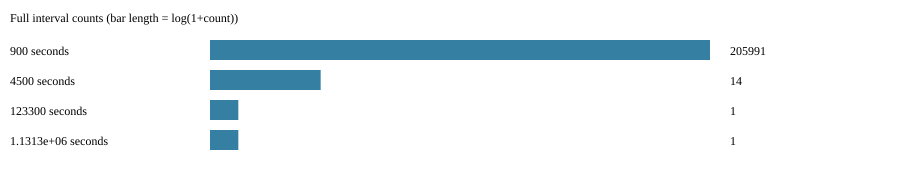

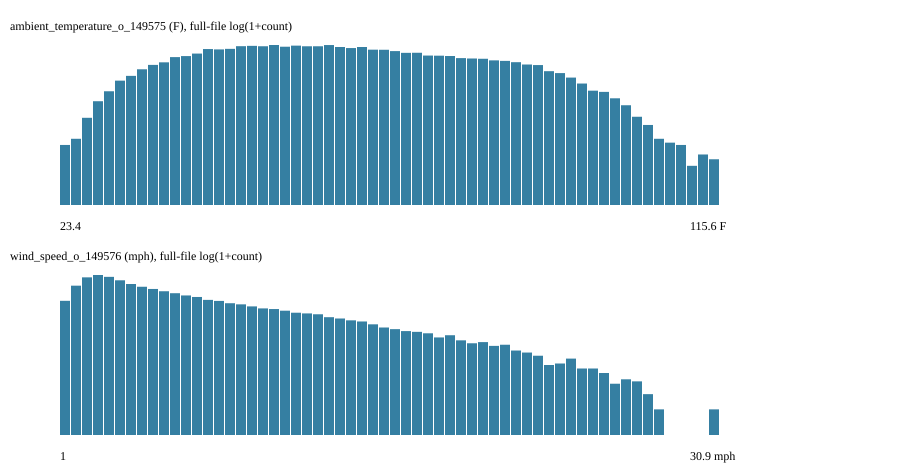

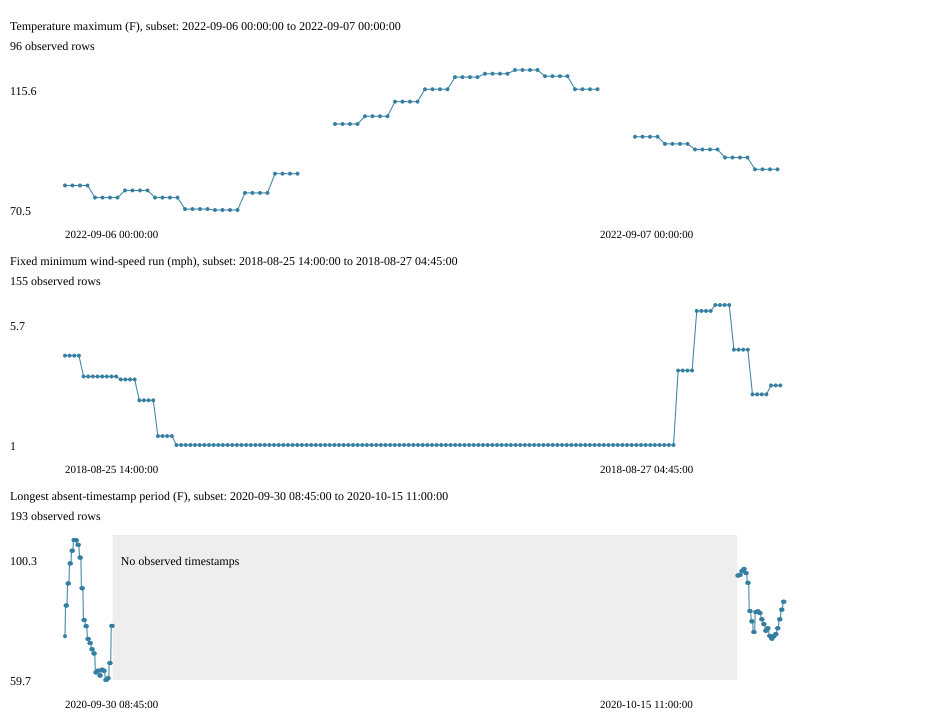

In [9]:
def show_svg(parts,width,height):
    display(SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"><rect width="100%" height="100%" fill="white"/>'+''.join(parts)+'</svg>'))
parts=['<text x="10" y="22">Full interval counts (bar length = log(1+count))</text>']
scale=np.log1p(interval_counts['count'].max())
for j,(interval,row) in enumerate(interval_counts.iterrows()):
    y=40+j*30; count=int(row['count'])
    parts.append(f'<text x="10" y="{y+15}">{interval:g} seconds</text><rect x="210" y="{y}" width="{500*np.log1p(count)/scale}" height="20" fill="#357fa2"/><text x="730" y="{y+15}">{count}</text>')
show_svg(parts,900,65+30*len(interval_counts))
parts=[]
for panel,c in enumerate([TEMP,SPEED]):
    finite=numeric[c][np.isfinite(numeric[c])].to_numpy()
    counts,edges=np.histogram(finite,bins=60); scale=np.log1p(counts.max()); top=30+panel*230
    units=metadata['Metrics'][c]['raw_units']
    parts.append(f'<text x="10" y="{top}">{html.escape(c)} ({units}), full-file log(1+count)</text>')
    for j,count in enumerate(counts):
        h=160*np.log1p(count)/scale
        parts.append(f'<rect x="{60+11*j}" y="{top+175-h}" width="10" height="{h}" fill="#357fa2"><title>{edges[j]:g} to {edges[j+1]:g}: {count}</title></rect>')
    parts.append(f'<text x="60" y="{top+200}">{edges[0]:g}</text><text x="690" y="{top+200}">{edges[-1]:g} {units}</text>')
show_svg(parts,900,465)
wind_longest=constant_runs[SPEED].loc[constant_runs[SPEED].rows.idxmax()]
windows=[('Temperature maximum',TEMP,pd.Timestamp('2022-09-06'),pd.Timestamp('2022-09-07')),
    ('Fixed minimum wind-speed run',SPEED,pd.Timestamp(wind_longest.start)-pd.Timedelta(hours=6),pd.Timestamp(wind_longest.end)+pd.Timedelta(hours=6)),
    ('Longest absent-timestamp period',TEMP,pd.Timestamp(longest_gap.gap_start)-pd.Timedelta(days=1),pd.Timestamp(longest_gap.gap_end)+pd.Timedelta(days=1))]
parts=[]
for panel,(title,c,start,end) in enumerate(windows):
    top=30+panel*235; mask=(parsed>=start)&(parsed<end); indices=np.flatnonzero(mask)
    values=numeric[c]; low=values[mask].min(); high=values[mask].max(); span=high-low or 1
    units=metadata['Metrics'][c]['raw_units']
    parts.append(f'<text x="10" y="{top}">{title} ({units}), subset: {start} to {end}</text><text x="10" y="{top+20}">{int(mask.sum())} observed rows</text>')
    if panel==2:
        gx=65+720*(pd.Timestamp(longest_gap.gap_start)-start)/(end-start)
        gw=720*(pd.Timestamp(longest_gap.gap_end)-pd.Timestamp(longest_gap.gap_start))/(end-start)
        parts.append(f'<rect x="{gx}" y="{top+35}" width="{gw}" height="145" fill="#eee"/><text x="{gx+8}" y="{top+65}">No observed timestamps</text>')
    previous=None
    for i in indices:
        if not np.isfinite(values.iloc[i]): previous=None; continue
        x=65+720*(parsed.iloc[i]-start)/(end-start); y=top+180-140*(values.iloc[i]-low)/span
        if previous is not None and seconds.iloc[i]==900:
            parts.append(f'<line x1="{previous[0]}" y1="{previous[1]}" x2="{x}" y2="{y}" stroke="#357fa2"/>')
        parts.append(f'<circle cx="{x}" cy="{y}" r="2" fill="#357fa2"><title>{raw_time.iloc[i]}: {values.iloc[i]:g}</title></circle>'); previous=(x,y)
    parts.append(f'<text x="10" y="{top+65}">{high:g}</text><text x="10" y="{top+185}">{low:g}</text><text x="65" y="{top+208}" font-size="11">{start}</text><text x="600" y="{top+208}" font-size="11">{end}</text>')
show_svg(parts,950,725)

## 9. Integrity and summary evidence
Recheck both permitted input hashes. No processed files or QC flags are generated.

In [10]:
for path in (CSV,META): assert sha256(path)==input_hashes[str(path.relative_to(ROOT))], 'Input changed during audit'
print('Input SHA-256 checks passed:',input_hashes)
display(pd.Series(coverage)); display(gap_summary); display(missingness)
display(statistics[['sensor','units','count','min','max','mean','median','zeros','negatives']])
display(repetition)
print('Longest missing interval:',longest_gap.gap_start,longest_gap.gap_end,longest_gap.duration,
      'candidate missing slots:',longest_gap.expected_15min_missing)

Input SHA-256 checks passed: {'data\\2107\\raw\\2107_environment_data.csv': '669f59c7bbcecc6d621788041188454986be1bf8a68c34ef544c2ef640404e06', 'data\\2107\\raw\\2107_system_metadata.json': '17e4f7f448fcb2bec43f7610b40c1f7f4fc794ccc185e41dcde0514afba73ae5'}
Longest missing interval: 2020-10-01 08:45:00 2020-10-14 11:00:00 13 days 02:15:00 candidate missing slots: 1256


wall_clock_duration           2160 days 23:45:00
rows                                      206008
naive_expected_slots                      207456
spring_slots_excluded                         24
conditional_expected_slots                207432
naive_absent_slots                          1448
non_dst_absent_slots                        1424
naive_present_pct                      99.302021
conditional_present_pct                 99.31351
dtype: object

,periods,candidate_slots,spring_slots,non_dst_slots
category,,,,
DST spring only,6,24,24,0
long non-DST,2,1392,0,1392
short non-DST,8,32,0,32


,sensor,valid_numeric_count,missing_count,missing_pct,first_missing,last_missing,runs,longest_run_rows,nonnumeric_count
0,ambient_temperature_o_149575,205876,132,0.064075,2018-02-03 09:00:00,2023-08-17 05:45:00,16,24,0
1,wind_speed_o_149576,205992,16,0.007767,2018-12-13 09:00:00,2020-11-04 09:45:00,4,4,0
2,wind_direction_o_149577,206000,8,0.003883,2018-12-13 09:00:00,2020-06-14 16:45:00,2,4,0


,sensor,units,count,min,max,mean,median,zeros,negatives
0,ambient_temperature_o_149575,F,205876,23.4,115.6,61.717315,60.3,0,0
1,wind_speed_o_149576,mph,205992,1.0,30.9,5.607143,4.2,0,0
2,wind_direction_o_149577,degree,206000,0.0,360.0,187.551757,162.0,312,0


,sensor,complete_valid_hours,constant_complete_hours,changes_by_minute
0,ambient_temperature_o_149575,51469,51469,{0: 50523}
1,wind_speed_o_149576,51498,51498,{0: 49280}
2,wind_direction_o_149577,51500,51500,{0: 50220}


# Environment Dataset Audit — Findings Requiring Cleaning Decisions

### A. Observed facts
- Four columns: timestamp plus ambient temperature (metric 149575, F), wind speed (149576, mph), and wind direction (149577, degree). Sensor names/IDs/units match metadata; scales are 1 and offsets 0. System-level metadata coverage dates differ from this file.
- 206,008 unique, strictly increasing timestamps from `2017-12-01 00:00:00` to `2023-10-31 23:45:00`; no parse failures, duplicate rows, or off-grid intervals. Modal grid: 15 minutes.
- Coverage benchmark: 2160 days 23:45 of wall-clock time, 207,456 naive 15-minute slots. Excluding 24 spring slots leaves 207,432 expected slots: 206,008 present (99.31351%) and 1,424 non-DST slots absent. Eight short gaps each contain four absent slots; two long gaps contain 1,392 slots. Longest interval: `2020-10-01 08:45:00` to `2020-10-14 11:00:00`, 13 days 02:15, 1,256 candidate absent samples.
- Six Pacific spring transitions skip 02:xx. Covered fall transitions retain only one set of 01:xx timestamps and omit 23:00-23:45 on the transition date. Fall handling remains unresolved and differs in detail from the reviewed electrical/irradiance cadence.
- Missing measurements: temperature 132 cells, wind speed 16, direction 8. 148 existing rows have at least one missing measurement; none has all three missing. The masks are not identical; missingness occurs in blocks. Temperature dropouts are independent; two four-row wind blocks affect speed and direction together, and two affect speed only.
- Temperature: 23.4?115.6 F, no zeros/negatives. Speed: 1.0?30.9 mph, no zeros/negatives. Direction: 0?360 degrees, with 312 exact zeros, 300 exact 360s, and none outside [0,360].
- Every complete, non-missing four-row hour has identical values for each sensor; all changes across adjacent valid 15-minute rows occur at minute 00. A 15-minute timestamp grid therefore does not establish independent 15-minute observations.
- Longest exact speed run is 1.0 mph for 108 rows, `2018-08-25 20:00:00` to `2018-08-26 22:45:00`. Longest direction runs span 16 rows (3:45 between endpoints). Complete gap, missing-block, run, and candidate tables appear above.

### B. Tentative interpretations
- Spring behavior and metadata support Pacific local wall-clock time, consistent broadly with electrical/irradiance. Fall-hour selection and missing late-evening hours need export documentation; no offsets are assigned.
- ?F to ?C and mph to m/s are mathematically straightforward once metadata conventions are accepted. No conversion is performed, and numerical ranges alone cannot verify calibration or units independently.
- Repeated hourly values suggest hourly source updates or an export hold/repetition convention. The mechanism is unconfirmed; these are not newly inferred measurements.
- Temperature/wind extrema can be plausible. Hour-boundary steps are review candidates, not proven isolated spikes. A repeated 1.0 mph minimum and long run may reflect calm-wind reporting, a sensor floor, or holding; none is established. No orders-of-magnitude numerical corruption is evident.
- Wind direction requires circular treatment for later averaging/interpolation; raw 0 and 360 remain distinct. Metadata does not establish reference/orientation. Large raw wrap jumps need not be large directional changes, and fixed hourly values alone do not prove a stuck sensor.
- Multi-day missing periods are unsafe to interpolate without evidence. Short gaps and sensor-only outages also require approval; no filling is assumed.

### C. Decisions still required
- Confirm source update rate/holding, fall export handling, and other timestamp omissions before alignment.
- Approve later unit conversions, zero-wind/minimum convention, and circular-direction rules.
- Decide whether exact runs, scalar step candidates, plausible extrema, and missingness deserve QC flags or removal. No removals are justified solely by this audit.
- Decide any short-gap policy separately from long outages. The audit implements no cleaning, flags, conversions, filling, resampling, or modelling decisions. Approved unit-only processing follows below.

## A. Approved cleaning rules
- Preserve 206,008 rows, raw timestamp strings, order, gaps, and missing sensor cells. No filling, UTC conversion, resampling, clipping, or magnitude-based replacements.
- Convert temperature F to C and wind speed mph to m/s; rename the three processed channels canonically. Keep direction numerically unchanged, including both 0 and 360.
- Keep the 15-minute grid and effectively hourly-changing values. The possible 1.0 mph floor and fall export behavior remain unresolved.
- No new corrupt observations or QC events are established; no separate QC file is generated.

In [11]:
import pyarrow as pa
import pyarrow.parquet as pq
EXPECTED_ROWS=206008
AUDIT_SHA256='669f59c7bbcecc6d621788041188454986be1bf8a68c34ef544c2ef640404e06'
assert sha256(CSV)==AUDIT_SHA256, 'Raw CSV differs from the reviewed audit'
assert len(frame)==EXPECTED_ROWS and header==[TIMESTAMP,TEMP,SPEED,DIRECTION]
assert metadata['Metrics'][TEMP]['raw_units']=='F'
assert metadata['Metrics'][SPEED]['raw_units']=='mph'
assert metadata['Metrics'][DIRECTION]['raw_units']=='degree'
assert missingness.set_index('sensor').missing_count.to_dict()=={TEMP:132,SPEED:16,DIRECTION:8}
assert missingness.nonnumeric_count.sum()==0 and statistics.infinities.sum()==0
print('Audited input and units confirmed; pyarrow',pa.__version__)

Audited input and units confirmed; pyarrow 25.0.1


## B. Unit conversion and processed data
Parse original numeric tokens with float64 round-trip precision, retaining existing NA cells. Only the approved formulas and names change. Raw Fahrenheit/mph columns are not duplicated in processed data.

In [12]:
raw_values={c:np.fromiter((np.nan if pd.isna(token) else float(token) for token in frame[c]),
                         dtype=np.float64,count=EXPECTED_ROWS) for c in CHANNELS}
processed=pd.DataFrame({
    TIMESTAMP:raw_time.to_numpy(copy=True),
    'ambient_temperature_c':(raw_values[TEMP]-32)*5/9,
    'wind_speed_m_s':raw_values[SPEED]*0.44704,
    'wind_direction_deg':raw_values[DIRECTION].copy(),
})
processed_names={TEMP:'ambient_temperature_c',SPEED:'wind_speed_m_s',DIRECTION:'wind_direction_deg'}
print('Processed columns:',processed.columns.tolist())
print('Missing cells:'); display(processed.isna().sum().rename('missing'))

Processed columns: ['measured_on', 'ambient_temperature_c', 'wind_speed_m_s', 'wind_direction_deg']
Missing cells:


measured_on                0
ambient_temperature_c    132
wind_speed_m_s            16
wind_direction_deg         8
Name: missing, dtype: int64

## C. Parquet output
The narrow four-column dataset fits in memory. Reruns replace only the derived environment Parquet file; raw inputs and other processed datasets are untouched.

In [13]:
assert sha256(CSV)==AUDIT_SHA256
OUTPUT_PATH=ROOT/'data/2107/processed/2107_environment_clean.parquet'
output_schema=pa.schema([(c,pa.string() if c==TIMESTAMP else pa.float64()) for c in processed.columns])
OUTPUT_PATH.parent.mkdir(parents=True,exist_ok=True)
pq.write_table(pa.Table.from_pandas(processed,schema=output_schema,preserve_index=False),
               OUTPUT_PATH,compression='snappy',row_group_size=50000)
print('Written:',OUTPUT_PATH.relative_to(ROOT))

Written: data\2107\processed\2107_environment_clean.parquet


## D. Validation
Read Parquet and independently reread only the raw environment CSV. Check every value against the approved formulas (absolute tolerance 1e-12, zero relative tolerance), exact direction/timestamps, missing masks, repeated rows, wind-floor readings, and both input hashes.

In [14]:
raw_check=pd.read_csv(CSV,dtype={c:np.float64 for c in CHANNELS},
                      converters={TIMESTAMP:str},float_precision='round_trip')
parquet_table=pq.read_table(OUTPUT_PATH)
assert parquet_table.schema.equals(output_schema,check_metadata=False)
roundtrip=parquet_table.to_pandas()
assert len(roundtrip)==len(raw_check)==EXPECTED_ROWS
assert list(roundtrip.columns)==[TIMESTAMP,'ambient_temperature_c','wind_speed_m_s','wind_direction_deg']
assert np.array_equal(roundtrip[TIMESTAMP].to_numpy(),raw_check[TIMESTAMP].to_numpy())
assert np.array_equal(raw_check[TIMESTAMP].to_numpy(),raw_time.to_numpy())
expected_values={
    TEMP:(raw_check[TEMP].to_numpy()-32)*5/9,
    SPEED:raw_check[SPEED].to_numpy()*0.44704,
    DIRECTION:raw_check[DIRECTION].to_numpy(),
}
validation_rows=[]
for raw_name,processed_name in processed_names.items():
    before=raw_check[raw_name].to_numpy(); after=roundtrip[processed_name].to_numpy()
    assert np.array_equal(np.isnan(before),np.isnan(after))
    np.testing.assert_allclose(after,expected_values[raw_name],rtol=0,atol=1e-12,equal_nan=True)
    if raw_name==DIRECTION:
        assert np.array_equal(before,after,equal_nan=True)
    # Preserve each adjacent repeated raw observation; gaps cannot hide row loss.
    repeated=(before[1:]==before[:-1]) & seconds.iloc[1:].eq(900).to_numpy()
    assert np.array_equal(after[1:][repeated],after[:-1][repeated])
    validation_rows.append(dict(raw_sensor=raw_name,processed_sensor=processed_name,
        missing_preserved=int(np.isnan(after).sum()),adjacent_repeats_preserved=int(repeated.sum()),
        approved_formula_verified=True))
assert roundtrip[['ambient_temperature_c','wind_speed_m_s','wind_direction_deg']].isna().sum().to_dict()=={
    'ambient_temperature_c':132,'wind_speed_m_s':16,'wind_direction_deg':8}
for endpoint in [0,360]:
    assert np.array_equal(raw_check[DIRECTION].eq(endpoint).to_numpy(),roundtrip.wind_direction_deg.eq(endpoint).to_numpy())
floor_mask=raw_check[SPEED].eq(1.0).to_numpy()
assert roundtrip.wind_speed_m_s.to_numpy()[floor_mask].size==int(floor_mask.sum())
assert np.all(roundtrip.wind_speed_m_s.to_numpy()[floor_mask]==0.44704)
for path in (CSV,META):
    assert sha256(path)==input_hashes[str(path.relative_to(ROOT))]
assert sha256(CSV)==AUDIT_SHA256
validation_report=dict(rows=len(roundtrip),timestamps_and_order_preserved=True,
    no_added_timestamps_or_filled_gaps=True,missing_cells_preserved=True,
    all_unit_conversions_verified=True,wind_direction_unchanged=True,
    direction_0_preserved=int(roundtrip.wind_direction_deg.eq(0).sum()),
    direction_360_preserved=int(roundtrip.wind_direction_deg.eq(360).sum()),
    wind_floor_values_preserved=int(floor_mask.sum()),quarter_hour_repetition_preserved=True,
    measurements_removed_or_replaced=0,parquet_types_verified=True,raw_sha256=AUDIT_SHA256)
display(pd.DataFrame(validation_rows))
display(pd.Series(validation_report,name='validation'))
print('Validation passed; raw CSV and metadata hashes unchanged. Only approved unit conversions and names changed.')

Validation passed; raw CSV and metadata hashes unchanged. Only approved unit conversions and names changed.


,raw_sensor,processed_sensor,missing_preserved,adjacent_repeats_preserved,approved_formula_verified
0,ambient_temperature_o_149575,ambient_temperature_c,132,155320,True
1,wind_speed_o_149576,wind_speed_m_s,16,156692,True
2,wind_direction_o_149577,wind_direction_deg,8,155761,True


rows                                                                             206008
timestamps_and_order_preserved                                                     True
no_added_timestamps_or_filled_gaps                                                 True
missing_cells_preserved                                                            True
all_unit_conversions_verified                                                      True
wind_direction_unchanged                                                           True
direction_0_preserved                                                               312
direction_360_preserved                                                             300
wind_floor_values_preserved                                                        1376
quarter_hour_repetition_preserved                                                  True
measurements_removed_or_replaced                                                      0
parquet_types_verified          